In [1]:
#Practical Logistic Regression machine learning program using a popular Kaggle dataset: 
#Titanic – Machine Learning from Disaster. 
#Kaggle Dataset Used 
#Dataset: Titanic Survival Dataset 
#Target: Survived (0 = No, 1 = Yes) 
#Features used: 
#• Pclass (Passenger class) 
#• Age 
#• Fare 

In [2]:
#Problem Statement 

#Build a Logistic Regression model to predict whether a passenger survived or not based on passenger details.

In [3]:
#Import Required Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
 
# from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import warnings
warnings.filterwarnings("ignore")


In [7]:
#Load Titanic Dataset (Downloaded from Kaggle) 
data = pd.read_csv("titanic_train.csv")   # use train.csv if downloaded from Kaggle 
print(data.head()) 
from sklearn.linear_model import LogisticRegression 
model=LogisticRegression()


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [16]:
#Select Features & Target 
# Select useful columns 
data = data[['Pclass', 'Age', 'Fare', 'Survived']] 

# Handle missing values 
data['Age'].fillna(data['Age'].mean(), inplace=True) 
 
X= data[['Pclass', 'Age', 'Fare']] 
y= data['Survived']

In [17]:
#Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) 


In [18]:
#Train Logistic Regression Model 
model = LogisticRegression(max_iter=1000) 
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
#Prediction 
y_pred = model.predict(X_test)

In [20]:
#Model Evaluation 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred)) 
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 
#Expected Accuracy: ~75–80%

Accuracy: 0.7354260089686099

Confusion Matrix:
 [[117  17]
 [ 42  47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.87      0.80       134
           1       0.73      0.53      0.61        89

    accuracy                           0.74       223
   macro avg       0.74      0.70      0.71       223
weighted avg       0.74      0.74      0.73       223



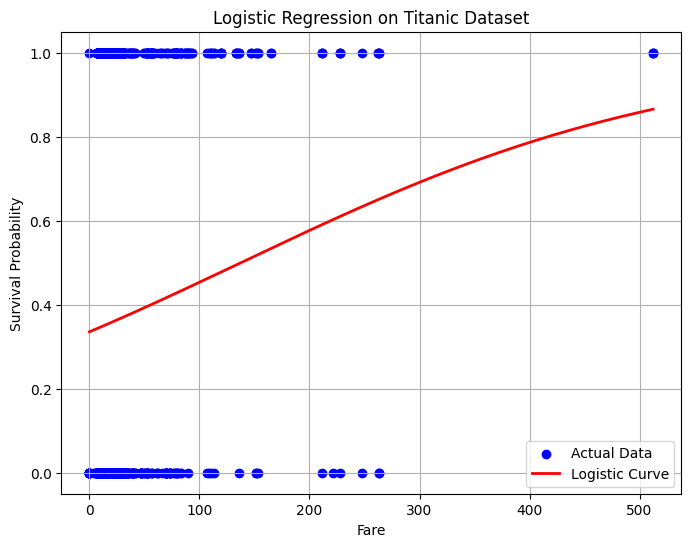

In [21]:
#Visualization (Survival Probability vs Fare) 
plt.figure(figsize=(8,6)) 
 
plt.scatter(X['Fare'], y, color='blue', label='Actual Data') 
 
fare_range = np.linspace(X['Fare'].min(), X['Fare'].max(), 200) 
age_mean = X['Age'].mean() 
pclass_mean = X['Pclass'].mean() 
X_plot = pd.DataFrame({ 
'Pclass': [pclass_mean]*200, 
'Age': [age_mean]*200, 
'Fare': fare_range 
}) 
y_prob = model.predict_proba(X_plot)[:,1] 
plt.plot(fare_range, y_prob, color='red', linewidth=2, label='Logistic Curve') 
plt.xlabel("Fare") 
plt.ylabel("Survival Probability") 
plt.title("Logistic Regression on Titanic Dataset") 
plt.legend() 
plt.grid(True) 
plt.show()